# 日経レバ1579 曜日別パフォーマンス分析

このノートブックでは、日経レバレッジETF（1579.T）の過去データを用いて、以下のパフォーマンスを曜日別に集計・分析します。

1. **曜日別 1日の騰落率 (Close to Close)**: 前日終値から当日終値までのリターン
2. **曜日別 オーバーナイト騰落率 (Prev Close to Open)**: 前日終値から当日始値までのリターン（窓開け）
3. **曜日別 日中騰落率 (Open to Close)**: 当日始値から当日終値までのリターン

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Meiryo', 'Yu Gothic', 'Hiragino Maru Gothic Pro', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def load_moomoo_csv(filepath):
    # thousands=',' to handle numbers like "58,940"
    df = pd.read_csv(filepath, thousands=',')
    
    # カラム名のマッピング（日本語から英語へ）
    column_map = {
        '日付': 'Date',
        '始値': 'Open',
        '高値': 'High',
        '安値': 'Low',
        '終値': 'Close',
        '出来高': 'Volume'
    }
    df = df.rename(columns=column_map)
    
    # 日付の変換とインデックス設定
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df = df.sort_index()
    
    # 必要なカラムのみ抽出して型を確実に変換
    cols = ['Open', 'High', 'Low', 'Close']
    for col in cols:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].str.replace('"', '').str.replace(',', '').astype(float)
            else:
                df[col] = df[col].astype(float)
    
    return df

In [2]:
symbol = "1579.T"
data_path_1579 = "../../moomoo/data/TimeChart(1579)20130509_20260502.csv"

df = load_moomoo_csv(data_path_1579)

# 2018年以降のデータを使用（直近の傾向を重視）
df = df[df.index >= "2018-01-01"]

# 曜日を追加 (0=Monday, 1=Tuesday, ..., 6=Sunday)
df['day_of_week'] = df.index.dayofweek
df['day_name'] = df.index.day_name()

# 各種リターンの計算
df['ret_daily'] = df['Close'].pct_change() # 前日終値 -> 当日終値
df['ret_overnight'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) # 前日終値 -> 当日始値
df['ret_intraday'] = (df['Close'] - df['Open']) / df['Open'] # 当日始値 -> 当日終値

# 異常値（欠損など）の除外
df = df.dropna()

print(f"Data Period: {df.index.min()} to {df.index.max()}")
print(f"Total Samples: {len(df)}")

Data Period: 2018-01-05 00:00:00 to 2026-05-01 00:00:00
Total Samples: 2030


## 1. 曜日別パフォーマンス集計

各リターン（1日全体、オーバーナイト、日中）の平均値を曜日ごとに算出します。

In [3]:
# 曜日順にソートするためのリスト
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# 集計
agg_stats = df.groupby('day_name').agg({
    'ret_daily': ['mean', 'std', 'count', lambda x: (x > 0).mean()],
    'ret_overnight': ['mean', 'std', lambda x: (x > 0).mean()],
    'ret_intraday': ['mean', 'std', lambda x: (x > 0).mean()]
}).reindex(days_order)

agg_stats.columns = [
    '1日リターン平均', '1日リターン標準偏差', 'サンプル数', '1日勝率',
    'オーバーナイト平均', 'オーバーナイト標準偏差', 'オーバーナイト勝率',
    '日中平均', '日中標準偏差', '日中勝率'
]

display(agg_stats.style.format("{:.2%}").format({"サンプル数": "{:.0f}"}))

,1日リターン平均,1日リターン標準偏差,サンプル数,1日勝率,オーバーナイト平均,オーバーナイト標準偏差,オーバーナイト勝率,日中平均,日中標準偏差,日中勝率
day_name,,,,,,,,,,
Monday,-0.000208,0.031972,372,0.545699,0.000233,0.025116,0.551075,-0.000455,0.019691,0.491935
Tuesday,0.004506,0.027933,414,0.577295,0.004560,0.022068,0.611111,-0.000062,0.016413,0.475845
Wednesday,0.001171,0.024233,416,0.485577,0.000561,0.018204,0.487981,0.000602,0.015371,0.487981
Thursday,0.000499,0.026271,413,0.508475,0.001194,0.022194,0.496368,-0.000673,0.015630,0.467312
Friday,-0.000067,0.025548,415,0.522892,-0.000340,0.020621,0.556627,0.000275,0.015089,0.513253


## 2. 可視化

平均リターンを棒グラフで比較します。

C:\Users\user\AppData\Local\Temp\ipykernel_27764\2202144339.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_stats.index, y=agg_stats['1日リターン平均'], ax=axes[0], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_27764\2202144339.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_stats.index, y=agg_stats['オーバーナイト平均'], ax=axes[1], palette='magma')
C:\Users\user\AppData\Local\Temp\ipykernel_27764\2202144339.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_stats.index, y=agg_stats['日中平均'], ax=axes[2], palette=

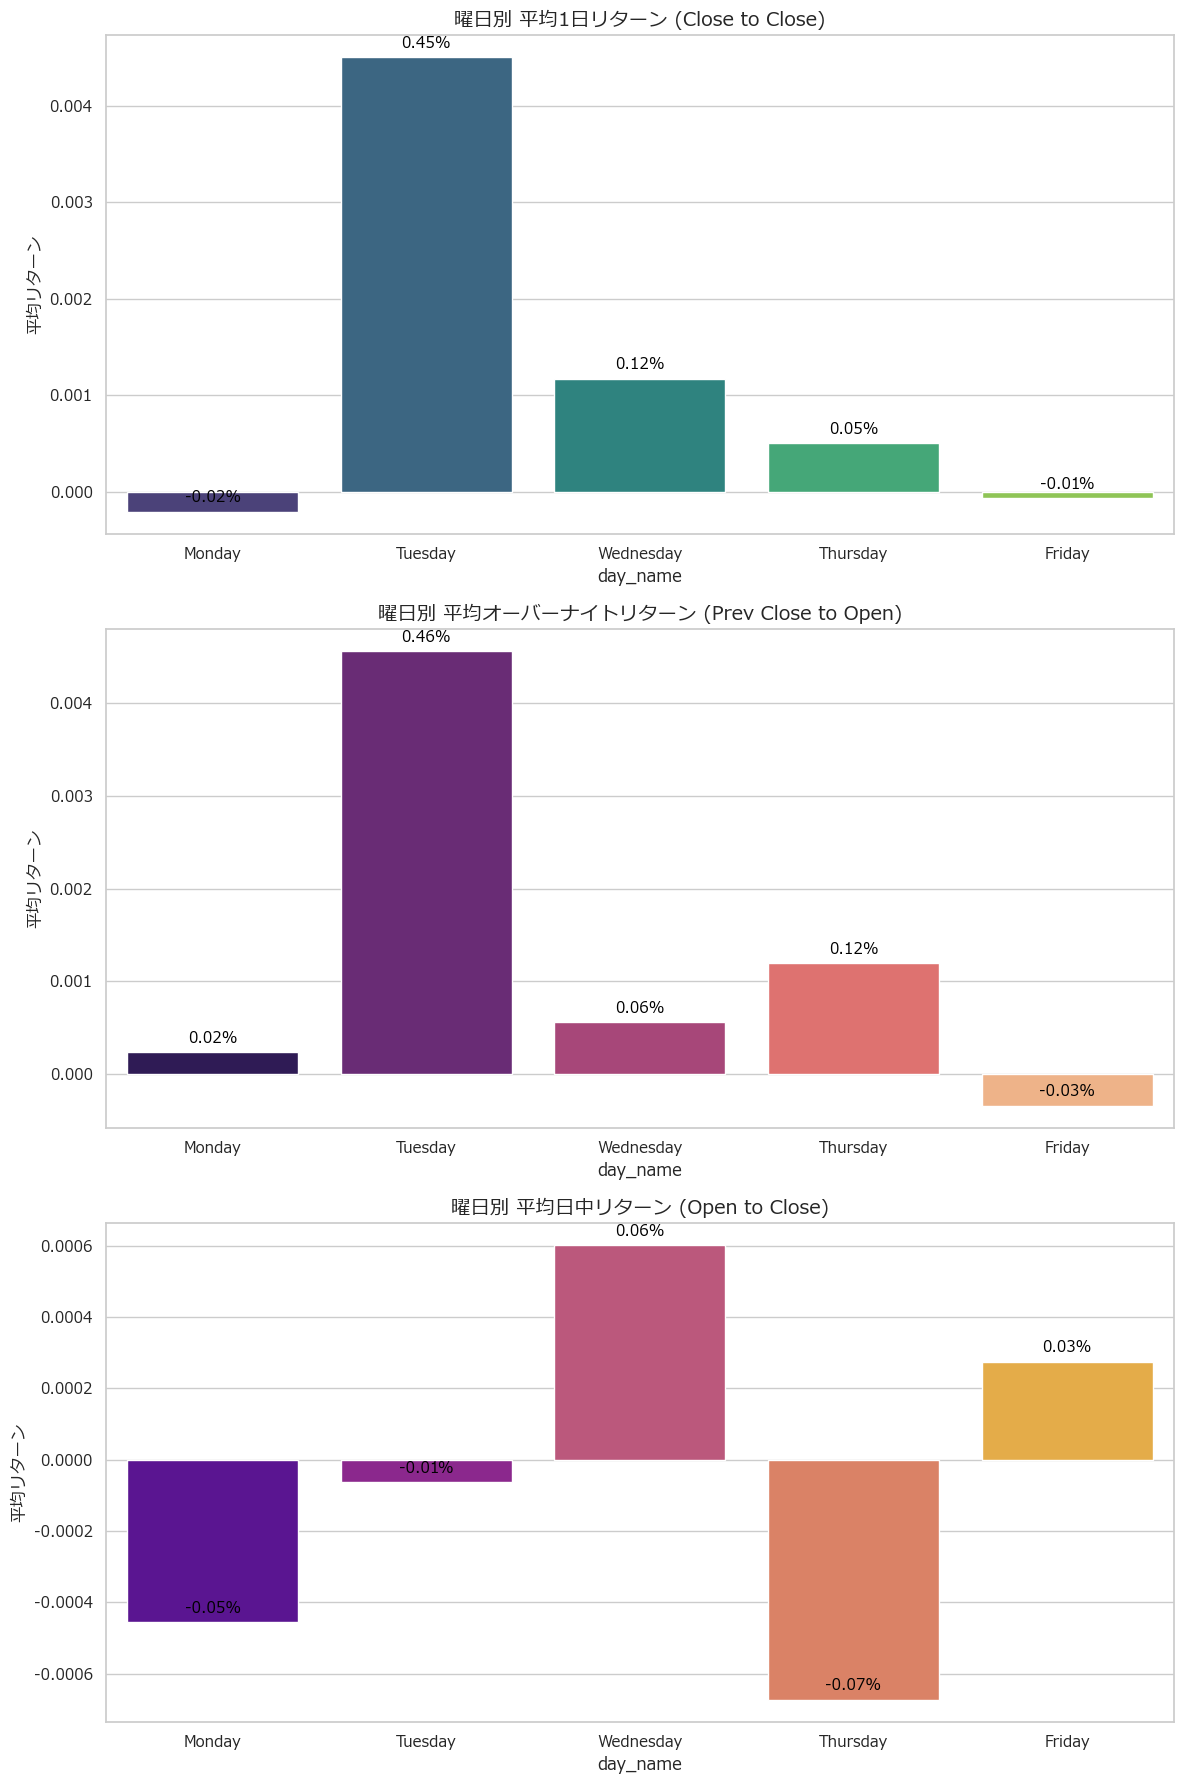

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. 1日全体
sns.barplot(x=agg_stats.index, y=agg_stats['1日リターン平均'], ax=axes[0], palette='viridis')
axes[0].set_title('曜日別 平均1日リターン (Close to Close)', fontsize=14)
axes[0].set_ylabel('平均リターン')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10), 
                textcoords='offset points')

# 2. オーバーナイト
sns.barplot(x=agg_stats.index, y=agg_stats['オーバーナイト平均'], ax=axes[1], palette='magma')
axes[1].set_title('曜日別 平均オーバーナイトリターン (Prev Close to Open)', fontsize=14)
axes[1].set_ylabel('平均リターン')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10), 
                textcoords='offset points')

# 3. 日中
sns.barplot(x=agg_stats.index, y=agg_stats['日中平均'], ax=axes[2], palette='plasma')
axes[2].set_title('曜日別 平均日中リターン (Open to Close)', fontsize=14)
axes[2].set_ylabel('平均リターン')
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. 累積リターンの比較（曜日別）

特定の曜日にのみポジションを持った場合の累積リターンをシミュレーションします。

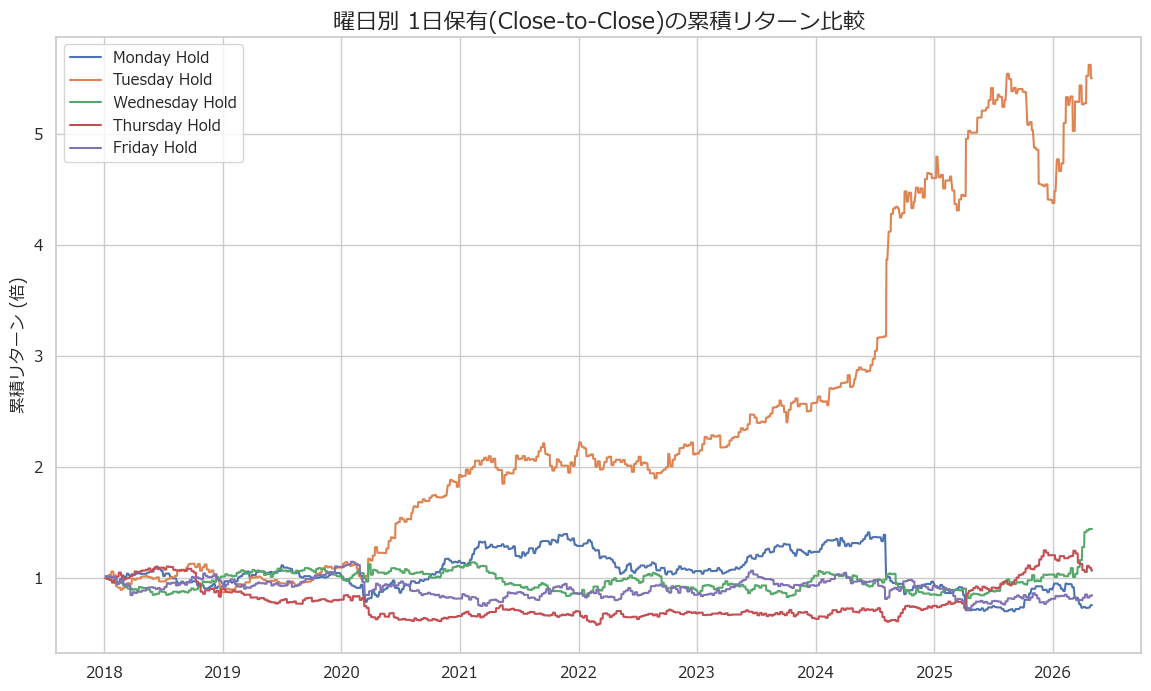

In [5]:
plt.figure(figsize=(14, 8))

for day in range(5):
    day_name = days_order[day]
    # その曜日だけトレード（1日全体）した場合のリターン
    day_ret = np.where(df['day_of_week'] == day, df['ret_daily'], 0)
    cum_ret = (1 + day_ret).cumprod()
    plt.plot(df.index, cum_ret, label=f'{day_name} Hold')

plt.title('曜日別 1日保有(Close-to-Close)の累積リターン比較', fontsize=16)
plt.ylabel('累積リターン (倍)')
plt.legend()
plt.show()

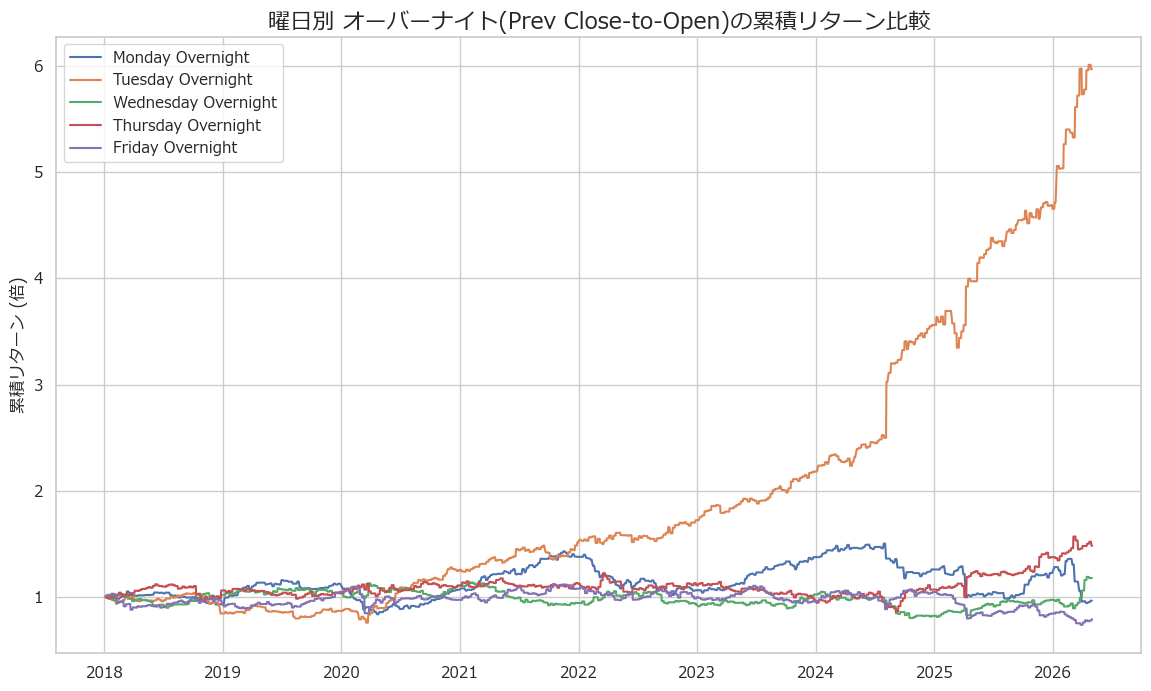

In [6]:
plt.figure(figsize=(14, 8))

for day in range(5):
    day_name = days_order[day]
    # その曜日だけトレード（オーバーナイトのみ）した場合のリターン
    day_ret = np.where(df['day_of_week'] == day, df['ret_overnight'], 0)
    cum_ret = (1 + day_ret).cumprod()
    plt.plot(df.index, cum_ret, label=f'{day_name} Overnight')

plt.title('曜日別 オーバーナイト(Prev Close-to-Open)の累積リターン比較', fontsize=16)
plt.ylabel('累積リターン (倍)')
plt.legend()
plt.show()

## 結論

- **月曜日**のパフォーマンス、特に**月曜朝の窓開け（オーバーナイト）**が他の曜日と比較してどのような特徴があるかを確認してください。
- 他の曜日（火曜日、水曜日など）にも特定の傾向が見られる場合があります。